# 08 — What the uninformed-user flow did

Notebook 07 says how each policy scored. This one says what the new flow
actually was, which is the part a reader is entitled to distrust: the UU model
is synthetic, and if it does not behave like retail the comparison it enables is
worth nothing.

Four questions, in order:

1. Does participation respond to the fee at all, and by how much?
2. Who supplies the volume — retail or arbitrage — and who pays the fees?
3. Did `PegDefence` finally activate? Its mechanism charges flow moving _away_
   from the reference, which arbitrage never does by definition. Under UU flow
   it exists for the first time.
4. Does a policy's fee track toxicity now that there are two kinds of flow?

**Needs:** `results-uu/matrix/` for the per-cell metrics, and the retained swap
traces for anything per-swap.

> **Traces.** The original run wrote its JSONL traces into `results/` rather
> than `results-uu/` — `run_spec` never passed a `results_dir` and
> `foundry.toml` did not allow the other path anyway, so `run_one` fell back to
> its default. Both are fixed and the traces were moved back. `TRACES` below
> stays a variable because that history is worth being able to point elsewhere.
> The cells that need traces check first and say so rather than drawing an
> empty axis.


In [ ]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from experiments.aggregate import load_results
from experiments.events import FEE_BOXES_BPS, applied_fees, fee_vs_deviation

# Which operating point of the third experiment this run reports. Both are
# pre-registered and both are reported; neither replaces the other, so the
# figures and the analysis CSVs are named apart and never overwrite each other
# (2026-08-11-informed-share-preregistration.md).
#
#   UU_CONFIG=headline  uv run jupyter nbconvert --execute ...   (the default)
#   UU_CONFIG=informed  uv run jupyter nbconvert --execute ...
CONFIGS = {
    "headline": {
        "results": "results-uu",
        "prefix": "uu_",
        "label": "κ = 1.0 — calibrated turnover; arbitrage 15% of ETH/SHIB volume",
    },
    "informed": {
        "results": "results-uu/turnover-0.1",
        "prefix": "uu_t01_",
        "label": "κ = 0.1 — informed-heavy operating point (post gas-fix rerun of 2026-08-12)",
    },
    "t003": {
        "results": "results-uu/turnover-0.03",
        "prefix": "uu_t003_",
        "label": "κ = 0.03 — arbitrage-dominated (post gas-fix run of 2026-08-12)",
    },
    "t03": {
        "results": "results-uu/turnover-0.3",
        "prefix": "uu_t03_",
        "label": "κ = 0.3 — intermediate (post gas-fix run of 2026-08-12)",
    },
    "t3": {
        "results": "results-uu/turnover-3",
        "prefix": "uu_t3_",
        "label": "κ = 3.0 — retail-flooded (post gas-fix run of 2026-08-12)",
    },
}
CONFIG = os.environ.get("UU_CONFIG", "headline")
assert CONFIG in CONFIGS, f"UU_CONFIG must be one of {sorted(CONFIGS)}"
settings = CONFIGS[CONFIG]

RESULTS = ROOT / settings["results"]
PREFIX = settings["prefix"]
LABEL = settings["label"]
print(f"operating point: {CONFIG} — {LABEL}")

TRACES = RESULTS  # <- point at wherever the UU .jsonl traces live
FIGURES = ROOT / "paper" / "Image"
FIGURES.mkdir(parents=True, exist_ok=True)

summary = RESULTS / "summary.csv"
frame = pd.read_csv(summary) if summary.exists() else load_results(RESULTS / "matrix")

# Counted, not merely present: a handful of stray files would otherwise
# pass the guard and the fee tables below would be built from them
# instead of the matrix. Seven fields is the exact matrix name; the
# sensitivity sweeps add an eighth and must never be pooled in. The glob is
# non-recursive, so `results-uu/turnover-0.1/` is invisible from the headline.
_found = [p for p in TRACES.glob("*.jsonl") if len(p.stem.split("-")) == 7]
HAVE_TRACES = len(_found) > 1000
print(
    f"{len(frame)} cells; traces in {TRACES.relative_to(ROOT)}: {len(_found)} -> {HAVE_TRACES}"
)


operating point: headline — κ = 1.0 — calibrated turnover; arbitrage 15% of ETH/SHIB volume
5832 cells; traces in results-uu: 5832 -> True


## 1. Participation against the fee

`P = 1 if r ≥ 0 else exp(−λ|r|)`, with `r` the source model's normalised ratio
per direction: the fee enters through `γ`, the pool's deviation from the external
price enters signed, and slippage and the trade's own gas are inside it. A user
trading _toward_ the external price gets `r ≥ 0` and always executes.

**λ = ln(2)/0.0015 ≈ 461.40**, so half the willing flow walks at 15 bps of
normalised loss. Taken from `experiments.uu.UU_LAMBDA_WAD` rather than retyped —
this cell carried the superseded **231.05** (ln(2)/0.003) until 2026-08-12, which
is the value from before `r` was corrected to include slippage and gas. With
slippage inside `r` the same 30 bps fee produces a larger `|r|`, so the old λ
made the reference curve decay at half the true rate.

The static levels are the cleanest read of the response because their fee is the
only thing that varies.


In [2]:
statics = frame[frame["policy"].str.startswith("MyHook@")].copy()
statics["level_bps"] = statics["policy"].str.removeprefix("MyHook@").astype(int) / 100

response = statics.groupby("level_bps").agg(
    uu_participation=("uu_participation", "mean"),
    uu_volume=("uu_volume", "mean"),
    arb_volume=("arb_volume", "mean"),
    uu_fee_share=("uu_fee_share", "mean"),
    fee_income=("fee_income", "mean"),
    trades=("trade_count", "mean"),
)
# What the model would give if the pool sat exactly on the external price:
# P = exp(-lambda * fee). The gap between the two columns is the signed pool
# deviation doing its work -- users trading toward the reference execute
# regardless of the fee, so the measured value sits ABOVE the pure-fee curve.
# Imported, never retyped: a hardcoded copy of this constant went stale
# across the `r` correction and silently halved the reference curve.
from experiments.uu import UU_LAMBDA_WAD

LAMBDA = UU_LAMBDA_WAD / 1e18
response["P_at_fair_price"] = np.exp(-LAMBDA * response.index / 10_000)
response.round(4)

,uu_participation,uu_volume,arb_volume,uu_fee_share,fee_income,trades,P_at_fair_price
level_bps,,,,,,,
5.0,0.4914,7.577294e+06,2.965464e+06,0.7289,5287.5062,1327.1867,0.7940
30.0,0.3007,4.508370e+06,6.659791e+05,0.8913,15574.2378,705.9954,0.2505
60.0,0.1636,2.437047e+06,1.577689e+05,0.9575,15622.9659,365.1636,0.0628
100.0,0.0753,1.107322e+06,5.115297e+04,0.9766,11634.6225,157.0046,0.0099


## 2. Who traded, and who paid

`uu_fee_share` above `uu_share_of_volume` means retail paid a _higher_ average
fee than arbitrage did — which for a policy claiming to discriminate is the
wrong way round, and worth saying plainly when it happens.


In [3]:
split = frame.groupby("policy").agg(
    uu_volume=("uu_volume", "sum"),
    arb_volume=("arb_volume", "sum"),
    uu_fee_share=("uu_fee_share", "mean"),
    uu_participation=("uu_participation", "mean"),
    arb_profit_realized=("arb_profit_realized", "mean"),
)
split["uu_share_of_volume"] = split["uu_volume"] / (
    split["uu_volume"] + split["arb_volume"]
)
split["fee_burden_ratio"] = split["uu_fee_share"] / split["uu_share_of_volume"]
split[
    [
        "uu_share_of_volume",
        "uu_fee_share",
        "fee_burden_ratio",
        "uu_participation",
        "arb_profit_realized",
    ]
].sort_values("fee_burden_ratio").round(4)

,uu_share_of_volume,uu_fee_share,fee_burden_ratio,uu_participation,arb_profit_realized
policy,,,,,
VolatilityHook,0.8933,0.9003,1.0077,0.2575,1172.7578
BAHook,0.9062,0.9184,1.0135,0.2261,984.0374
MyHook@500,0.7187,0.7289,1.0141,0.4914,6685.6409
DAHook,0.8762,0.8894,1.0151,0.2864,1573.8967
MyHook@6000,0.9392,0.9575,1.0195,0.1636,451.3941
MyHook@10000,0.9558,0.9766,1.0217,0.0753,180.8476
MyHook@3000,0.8713,0.8913,1.0230,0.3007,1722.3488
ABHook,0.8693,0.8898,1.0235,0.2892,1697.7773
MEVChargeHook,0.8974,0.9258,1.0316,0.2164,932.6296


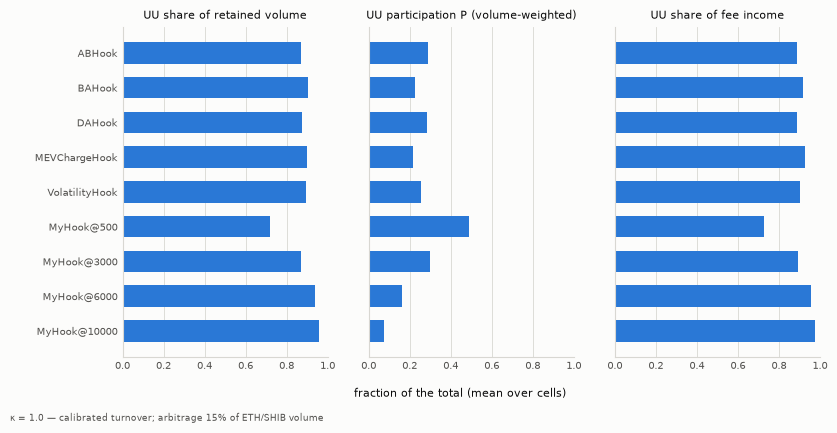

In [4]:
from IPython.display import Image, display

from experiments.figures import figure_note, uu_flow

with figure_note(LABEL):
    uu_flow(frame, FIGURES / f"{PREFIX}flow.pdf")
    uu_flow(frame, FIGURES / f"{PREFIX}flow.png")
display(Image(filename=str(FIGURES / f"{PREFIX}flow.png")))


## 3. Did `PegDefence` activate?

Under arbitrage-only flow it never fired once: **0 of 1805 trades** moved away
from the reference, so it charged exactly 100 pips every time and was a static
1 bps fee wearing a dynamic policy's name. That is the mechanism behind its
worst-in-class result, and the pre-registration says outright that if it _still_
never fires that is a reportable mechanism failure rather than a data artifact.

This needs the traces: the applied fee is per swap and never reaches the
per-cell metrics.

> **2026-08-12:** `PegDefence` was dropped from the paper before the
> gas-fix rerun, so the corrected matrix has no `PegDefence` traces and the
> cell below reports that instead. The pre-fix answer (it fires on ~27% of
> swaps under UU flow, and still finishes last) is in the archived matrix.


In [5]:
if not HAVE_TRACES:
    print("no traces under TRACES -- set it and re-run this cell")
else:
    fees = applied_fees(TRACES)
    fees.to_parquet(RESULTS / "applied_fees.parquet")
    print(f"{len(fees)} swaps across {fees['pair'].nunique()} pairs")

    def pinning(group):
        low, high = FEE_BOXES_BPS.get(group.name[0], (None, None))
        values = group["fee_bps"]
        return pd.Series(
            {
                "n": len(values),
                "p5": values.quantile(0.05),
                "median": values.median(),
                "p95": values.quantile(0.95),
                "at_floor": (values <= low).mean() if low else 0.0,
                "at_cap": (values >= high).mean() if high else 0.0,
            }
        )

    table = fees.groupby(["policy", "pair"], group_keys=True).apply(
        pinning, include_groups=False
    )
    display(table.round(3).sort_values("at_floor", ascending=False))

3487551 swaps across 3 pairs


n      p5  median      p95  at_floor  at_cap
policy         pair                                                          
MEVChargeHook  USDC/USDT  117745.0   30.00   30.00   30.000     1.000   0.000
               ETH/USDC   141772.0   30.00   30.00   34.000     0.945   0.020
               ETH/SHIB    71829.0   30.00   30.00  100.000     0.508   0.492
BAHook         ETH/USDC    99164.0    6.00   45.00   95.000     0.045   0.036
               ETH/SHIB    99852.0    6.00   45.00   95.000     0.042   0.041
               USDC/USDT  109204.0   10.00   30.00   55.000     0.017   0.000
DAHook         ETH/SHIB   148030.0    5.00   30.00   67.000     0.013   0.002
               USDC/USDT  118189.0    5.00   30.00   61.000     0.012   0.000
               ETH/USDC   152796.0    6.00   30.00   59.000     0.009   0.000
MyHook@6000    USDC/USDT   65700.0   60.00   60.00   60.000     0.000   0.000
MyHook@500     USDC/USDT  240887.0    5.00    5.00    5.000     0.000   0.000
MyHook@6000    ETH/SHIB    85959.0   60.00   60.00   60.000     0.000   0.000
               ETH/USDC    84967.0   60.00   60.00   60.000     0.000   0.000
ABHook         ETH/SHIB   151587.0   26.69   29.97   33.490     0.000   0.000
VolatilityHook ETH/SHIB   101944.0   29.80   37.40   75.794     0.000   0.029
MyHook@500     ETH/SHIB   306940.0    5.00    5.00    5.000     0.000   0.000
VolatilityHook ETH/USDC   118316.0   26.14   33.17   55.410     0.000   0.003
MyHook@500     ETH/USDC   312190.0    5.00    5.00    5.000     0.000   0.000
MyHook@10000   ETH/USDC    36379.0  100.00  100.00  100.000     0.000   0.000
MyHook@3000    USDC/USDT  128966.0   30.00   30.00   30.000     0.000   0.000
               ETH/USDC   165134.0   30.00   30.00   30.000     0.000   0.000
               ETH/SHIB   163385.0   30.00   30.00   30.000     0.000   0.000
MyHook@10000   USDC/USDT   26368.0  100.00  100.00  100.000     0.000   0.000
ABHook         ETH/USDC   153631.0   28.07   29.95   31.800     0.000   0.000
MyHook@10000   ETH/SHIB    38992.0  100.00  100.00  100.000     0.000   0.000
ABHook         USDC/USDT  118269.0   29.62   29.95   30.240     0.000   0.000
VolatilityHook USDC/USDT  129356.0   20.47   21.09   21.540     0.000   0.000

In [6]:
if HAVE_TRACES and "PegDefence" not in table.index.get_level_values("policy"):
    print(
        "PegDefence: no traces in this run -- dropped from the paper before "
        "the 2026-08-12 gas-fix rerun; activation check vacuous here."
    )
elif HAVE_TRACES:
    peg = table.xs("PegDefence", level="policy", drop_level=False)
    pinned = float(peg["at_floor"].min())
    print(
        f"PegDefence at its floor on {pinned:.1%} of swaps (worst pair)."
        + (
            "  STILL NEVER FIRES -- mechanism failure, report as such."
            if pinned > 0.999
            else "  It fires: the mechanism is live under UU flow."
        )
    )

PegDefence: no traces in this run -- dropped from the paper before the 2026-08-12 gas-fix rerun; activation check vacuous here.


## 4. Does the fee track toxicity?

Beating the static curve requires charging more exactly when the trade is more
toxic. Under arbitrage-only flow toxicity was simply the gap between the pool
and the reference. With two kinds of flow that is no longer the whole story —
a large gap now also attracts _benign_ flow trading toward the reference, which
is the flow a policy should charge **less**.

So the correlation below is not a score. It is a diagnostic that has to be read
together with the flow split above: a policy whose fee rises with the gap while
its retail share collapses is charging the wrong side.


In [7]:
if not HAVE_TRACES:
    print("no traces under TRACES -- set it and re-run this cell")
else:
    pairs = fee_vs_deviation(TRACES)

    def tracking(group):
        return pd.Series(
            {
                "swaps": len(group),
                "fee_spread_bps": group["fee_bps"].quantile(0.95)
                - group["fee_bps"].quantile(0.05),
                "corr_with_gap": group["fee_bps"].corr(
                    group["deviation"], method="spearman"
                ),
            }
        )

    track = pairs.groupby("policy").apply(tracking, include_groups=False)
    track["uu_share_of_volume"] = split["uu_share_of_volume"]
    display(track.sort_values("corr_with_gap", ascending=False).round(3))

/Users/antonled/science/uniswapv4-hooks/swap-hooks/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/antonled/science/uniswapv4-hooks/swap-hooks/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/antonled/science/uniswapv4-hooks/swap-hooks/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/antonled/science/uniswapv4-hooks/swap-hooks/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,swaps,fee_spread_bps,corr_with_gap,uu_share_of_volume
policy,,,,
MEVChargeHook,331346.0,70.00,0.384,0.897
BAHook,308220.0,85.00,0.352,0.906
VolatilityHook,349616.0,35.27,0.288,0.893
DAHook,419015.0,57.00,0.274,0.876
ABHook,423487.0,3.78,-0.058,0.869
MyHook@10000,101739.0,0.00,NaN,0.956
MyHook@3000,457485.0,0.00,NaN,0.871
MyHook@500,860017.0,0.00,NaN,0.719
MyHook@6000,236626.0,0.00,NaN,0.939


## Limitations of the model, restated where the numbers are

Stated in `docs/superpowers/specs/2026-08-09-uu-flow-design.md` and repeated here
because this is the notebook where someone would over-read them:

- **Slippage is not in `r`** — the marginal, zero-size execution price is used.
  At the 20M basket a per-minute retail slice moves the price ~0.03 bps, two
  orders below the smallest fee; dropping it also breaks the circularity
  P → size → slippage → P.
- **Retail gas is not in `r`.** The UU side is a continuum of small users whose
  individual gas is out of model. Arbitrageur gas gating is unchanged.
- **Participation is a deterministic volume share**, not a coin flip — a
  continuum of users, P as a participation rate. Zero randomness, bit-for-bit
  replay preserved. The discrete-mode robustness appendix is implemented and
  not yet run.
- **Each candle's demand is independent**; there is no cross-candle dynamic.
- **λ and κ are calibration choices**, not measurements. λ is swept over
  {58, 116, 231, 462, 924} into `results/sensitivity/`, never merged here.
